# Задание Ultra Pro
Каждый из нас писал в школе и университете изложения, сочинения, рефераты. А значит, в каждом из нас живет великий русский писатель.
В этой работе будем раскрывать свои таланты, находить себя в ряду таких гениев, как Пушкин, Гоголь, Грибоедов

В этой работе
- скачаем корпус текстов 20-ми русских писателей. Каждый текст разобьем на обучающую и тестовую выборки.
- разработаем и обучим нейронную сеть определяющию авторство фрагментов текста (по тестовой выборке)
- скачаем СВОЕ сочинение (или чье-нибудь - есть в архиве). Сделаем из него проверочную выборку
- предложим нейронке предсказать автора сочинения (по проверочной выборке)
- объявим себя великим писателем, например, Гончаровым

Ссылка на архив: https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

В работе рекомендуется пользоваться материалами из ноутбука практического занятия "Рекуррентные и одномерные сверточные нейронные сети". Допускается выбрать лучший вариант нейронки и адаптировать ее структуру, параметры обучения и формирования датасетов под свои *нужды*

In [ ]:
# ваше решение

In [ ]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, GRU, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [ ]:
!wget -q -O 20writers.zip https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

with zipfile.ZipFile('20writers.zip', 'r') as zip_ref:
    zip_ref.extractall('20writers')

In [ ]:
txt_files = []

for root, dirs, files in os.walk('20writers'):
    for file in files:
        if file.lower().endswith('.txt'):
            txt_files.append(os.path.join(root, file))

print('Найдено txt-файлов:', len(txt_files))
print(txt_files[:10])

Найдено txt-файлов: 20
['20writers/Тургенев.txt', '20writers/Лесков.txt', '20writers/Гоголь.txt', '20writers/Катаев.txt', '20writers/Пушкин.txt', '20writers/Шолохов.txt', '20writers/Каверин.txt', '20writers/Толстой.txt', '20writers/Горький.txt', '20writers/Достоевский.txt']


In [ ]:
texts = []
authors = []

for file_name in sorted(os.listdir('20writers')):
    if file_name.endswith('.txt'):
        file_path = os.path.join('20writers', file_name)
        author = file_name.replace('.txt', '')

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read().replace('\n', ' ')

        texts.append(text)
        authors.append(author)

CLASS_LIST = authors
CLASS_COUNT = len(CLASS_LIST)

print('Количество авторов:', CLASS_COUNT)
print(CLASS_LIST)

Количество авторов: 20
['Беляев', 'Булгаков', 'Васильев', 'Гоголь', 'Гончаров', 'Горький', 'Грибоедов', 'Достоевский', 'Каверин', 'Катаев', 'Куприн', 'Лермонтов', 'Лесков', 'Носов', 'Пастернак', 'Пушкин', 'Толстой', 'Тургенев', 'Чехов', 'Шолохов']


In [ ]:
text_train = []
text_test = []

# разбиение текста на слова
for text in texts:
    words = text.split()
    # фомирование выборок
    border = int(len(words) * 0.8)

    train_part = ' '.join(words[:border])
    test_part = ' '.join(words[border:])

    text_train.append(train_part)
    text_test.append(test_part)

print('Обучающих текстов:', len(text_train))
print('Проверочных текстов:', len(text_test))

Обучающих текстов: 20
Проверочных текстов: 20


In [ ]:
VOCAB_SIZE = 40000
WIN_SIZE = 1000
WIN_HOP = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff', lower=True, split=' ', oov_token='неизвестное_слово')
tokenizer.fit_on_texts(text_train)
# преобразование текстов в числовые последовательности
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

# разбиаение последовательностей на окна
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop) if len(sequence[i:i + win_size]) == win_size]

# создание выборки фрагментов х и меток у, каждому окну приписывается автор
def vectorize_sequence(seq_list, win_size, hop):
    x = []
    y = []

    for cls in range(CLASS_COUNT):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x.extend(vectors)
        y.extend([utils.to_categorical(cls, CLASS_COUNT)] * len(vectors))

    return np.array(x), np.array(y)

# итоговые выборки
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

x_train: (34585, 1000)
y_train: (34585, 20)
x_test: (8578, 1000)
y_test: (8578, 20)


In [ ]:
model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=WIN_SIZE),
    SpatialDropout1D(0.3),

    Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),

    Conv1D(96, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),

    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),

    Dense(CLASS_COUNT, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

Epoch 1/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.2727 - loss: 2.4887 - val_accuracy: 0.3486 - val_loss: 2.2499
Epoch 2/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.7234 - loss: 1.0059 - val_accuracy: 0.6619 - val_loss: 1.2254
Epoch 3/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8977 - loss: 0.3935 - val_accuracy: 0.7087 - val_loss: 1.1064
Epoch 4/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9371 - loss: 0.2289 - val_accuracy: 0.7097 - val_loss: 1.1903
Epoch 5/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9541 - loss: 0.1625 - val_accuracy: 0.7012 - val_loss: 1.2893
Epoch 6/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9614 - loss: 0.1315 - val_accuracy: 0.7167 - val_loss: 1.3099
Epoch 7/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9658 - loss: 0.1102 - val_accuracy: 0.7180 - val_loss: 1.3798
Epoch 8/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9675 - loss: 0.1044 - 

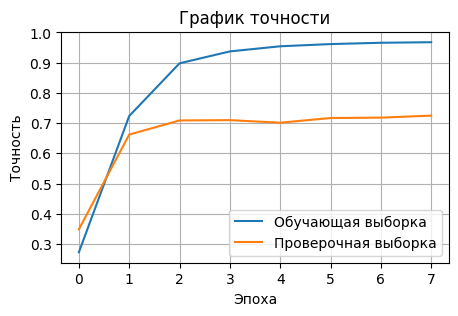

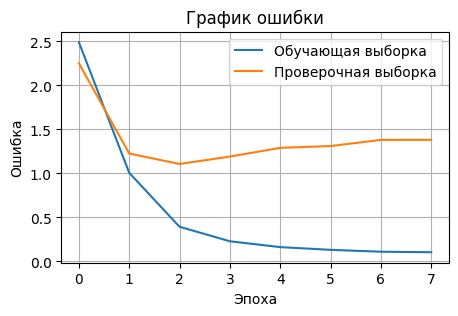

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('График точности')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.title('График ошибки')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# определение автора
def predict_author(text):
    # преобразование в последовательность чисел
    sequence = tokenizer.texts_to_sequences([text])[0]
    # разбиаение на окна
    fragments = split_sequence(sequence, WIN_SIZE, WIN_HOP)

    # если короткий текст
    if len(fragments) == 0:
        # дополнение нулями до нужной длины
        fragments = pad_sequences([sequence], maxlen=WIN_SIZE, padding='post', truncating='post')
    else:
        # перевод в массив
        fragments = np.array(fragments)

    # получение предсказания
    predictions = model.predict(fragments)
    # усреднение вероятностей для общего результата
    mean_prediction = predictions.mean(axis=0)

    # таблица вероятностей
    result = pd.DataFrame({'Автор': CLASS_LIST, 'Вероятность': mean_prediction})
    result = result.sort_values('Вероятность', ascending=False).reset_index(drop=True)

    return result

In [ ]:
my_text = '''
Розы красны,
Фиалки голубы,
Я хотела бы домой, да не могу,
Ведь тогда жизнь моя будет печальной.
Я долго смотрела в окно и думала как странно устроены люди.
Каждый делает вид -- он знает дорогу, хотя сам часто идёт наугад.
Вечер был тихий, воздух -- тяжёлым, и всё вокруг
Словно ждало решения
Откуда-то сверху
'''
prediction_df = predict_author(my_text)

display(prediction_df.head(10))

print('Наиболее похожий автор:', prediction_df.iloc[0]['Автор'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step


,Автор,Вероятность
0,Чехов,0.956626
1,Достоевский,0.012051
2,Гоголь,0.010782
3,Горький,0.008360
4,Куприн,0.001917
5,Носов,0.001890
6,Толстой,0.001692
7,Булгаков,0.001114
8,Гончаров,0.000924
9,Тургенев,0.000804


Наиболее похожий автор: Чехов


In [ ]:
# фрагмент Человек в футляре Чехова
my_text = '''
На самом краю села Мироносицкого, в сарае старосты Прокофия, расположились на ночлег запоздавшие охотники. Их было только двое: ветеринарный врач Иван Иваныч и учитель гимназии Буркин. Иван Иваныч имел довольно странную, двойную фамилию — Чимша-Гималайский, которая совсем не шла ему, и его во всей губернии звали просто по имени и отчеству.
'''
prediction_df = predict_author(my_text)

display(prediction_df.head(10))

print('Наиболее похожий автор:', prediction_df.iloc[0]['Автор'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,Автор,Вероятность
0,Чехов,0.606682
1,Лесков,0.070892
2,Шолохов,0.070856
3,Носов,0.053441
4,Тургенев,0.034559
5,Гоголь,0.034011
6,Васильев,0.032336
7,Куприн,0.024120
8,Каверин,0.011727
9,Пастернак,0.010440


Наиболее похожий автор: Чехов


In [ ]:
# фрагмент Гранатовый браслет Куприна
my_text = '''
В середине августа, перед рождением молодого месяца, вдруг наступили отвратительные погоды, какие так свойственны северному побережью Чёрного моря. По целым суткам тяжело лежал над землёй густой туман, и тогда огромная сирена на маяке ревела днём и ночью, точно бешеный бык. С утра до утра моросил мелкий, как водяная пыль, дождик, превращавший глинистые дороги и тропинки в сплошную густую грязь.
'''
prediction_df = predict_author(my_text)

display(prediction_df.head(10))

print('Наиболее похожий автор:', prediction_df.iloc[0]['Автор'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


,Автор,Вероятность
0,Куприн,0.366975
1,Катаев,0.154285
2,Каверин,0.085443
3,Тургенев,0.067732
4,Чехов,0.067044
5,Достоевский,0.037518
6,Васильев,0.034985
7,Шолохов,0.034427
8,Пастернак,0.025023
9,Гоголь,0.022217


Наиболее похожий автор: Куприн


In [ ]:
# фрагмент Обломов Гончарова
my_text = '''
В Гороховой улице, в одном из больших домов, народонаселения которого стало бы на целый уездный город, лежал утром в постели, на своей квартире, Илья Ильич Обломов. Это был человек лет тридцати двух-трёх от роду, среднего роста, приятной наружности, с тёмно-серыми глазами, но с отсутствием всякой определённой идеи в чертах лица.
'''
prediction_df = predict_author(my_text)

display(prediction_df.head(10))

print('Наиболее похожий автор:', prediction_df.iloc[0]['Автор'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


,Автор,Вероятность
0,Гончаров,0.998442
1,Каверин,0.001180
2,Толстой,0.000142
3,Носов,0.000111
4,Достоевский,0.000085
5,Горький,0.000014
6,Беляев,0.000008
7,Куприн,0.000008
8,Пушкин,0.000003
9,Тургенев,0.000003


Наиболее похожий автор: Гончаров
